<a href="https://colab.research.google.com/github/Sharanya1804/NIDS/blob/main/NIDS_Trainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Libraries and Environment Setup
**What it does:**
- Installs necessary packages: `scikit-learn` for ML, `xgboost` for advanced gradient boosting, and `joblib` for model persistence.
- Imports standard data science tools (`pandas`, `numpy`) and visualization libraries (`matplotlib`, `seaborn`).

**Important Points:**
- **XGBoost:** Included because it often outperforms standard algorithms on tabular data like network logs.
- **Warnings:** `warnings.filterwarnings("ignore")` is used to keep the notebook clean from version deprecation alerts.

In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import joblib
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries loaded!")

✅ All libraries loaded!


### 2. Data Acquisition
**What it does:**
- Downloads the **NSL-KDD** dataset, which is a refined version of the classic KDD'99 dataset designed to remove redundant records that could bias models.
- Assigns 42 specific column names manually since the raw CSVs lack headers.



In [4]:
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt -O KDDTrain.csv
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt  -O KDDTest.csv

# Column names for NSL-KDD
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train_df = pd.read_csv("KDDTrain.csv", names=col_names)
test_df  = pd.read_csv("KDDTest.csv",  names=col_names)

# Drop difficulty column
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty",  axis=1, inplace=True)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print("\nLabel distribution:\n", train_df["label"].value_counts())

Train shape: (125973, 42)
Test shape:  (22544, 42)

Label distribution:
 label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
display(train_df.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


### 3. Preprocessing and Feature Engineering
**What it does:**
- **Label Transformation:** Converts the multi-class labels (e.g., 'neptune', 'satan') into a binary format: `0` for normal and `1` for any type of attack.
- **Categorical Encoding:** Uses `LabelEncoder` on 'protocol_type', 'service', and 'flag' to turn text into numbers.
- **Scaling:** Applies `StandardScaler` so that high-magnitude features (like 'src_bytes') don't overwhelm small-magnitude features (like 'hot' counts).

**Important Points:**
- **Stratification:** When splitting data, `stratify=y` ensures the ratio of attacks to normal traffic is the same in both the training and testing sets, preventing a biased evaluation.

### Key Preprocessing Steps

1. **Label Encoding**
   - Converts categorical text labels into numerical values so the machine learning model can process them.
   - *Example:* `tcp` → 0, `udp` → 1, `icmp` → 2; `http` → 0, `ftp` → 1, `smtp` → 2.

2. **Binary Classification**
   - Simplifies the multi-class problem into a detection problem:
   - `"normal"` → **0**
   - `any attack` → **1** (Aggregates labels like 'neptune', 'smurf', and 'portsweep' into a single 'Attack' category).

3. **Standard Scaling**
   - Rescales features to have a mean of 0 and a standard deviation of 1.
   - *Why:* Prevents features with large ranges (like `src_bytes` or `duration`) from dominating the model's weight calculations compared to smaller numerical features.

4. **Train/Test Split**
   - The dataset is divided to ensure a fair evaluation:
   - **80% Training Set:** Used for the model to learn patterns and features.
   - **20% Test Set:** Held back as 'unseen' data to evaluate how the model performs in a real-world scenario.

In [19]:
df = pd.concat([train_df, test_df], ignore_index=True)

# ── Binary classification: normal vs attack ──────────────────
df["label_binary"] = df["label"].apply(lambda x: 0 if x == "normal" else 1)

# ── Encode categorical columns ────────────────────────────────
cat_cols = ["protocol_type", "service", "flag"]
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le          # save encoders for VS Code inference

# ── Features & target ─────────────────────────────────────────
X = df.drop(["label", "label_binary"], axis=1)
y = df["label_binary"]

feature_names = X.columns.tolist()

# ── Scale ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train / test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Attack ratio in train: {y_train.mean():.2%}")

X_train: (118813, 41) | X_test: (29704, 41)
Attack ratio in train: 48.12%


### 4. Model Competition
**What it does:**
- Trains two powerful ensemble models: **Random Forest** and **XGBoost**.
- Compares them using the **F1-Score**, which is more reliable than simple Accuracy if the dataset has imbalanced classes.

**Important Points:**
- **Ensemble Power:** By trying both, we ensure we use the model that generalizes best to unseen network traffic. In this run, **XGBoost** was selected as the winner.

In [20]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=100, use_label_encoder=False,
                                   eval_metric="logloss", random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    results[name] = {"model": model, "acc": acc, "f1": f1, "preds": y_pred}
    print(f"   Accuracy : {acc:.4f}")
    print(f"   F1-Score : {f1:.4f}")

# ── Pick best model ───────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_name]["model"]
print(f"\n🏆 Best model: {best_name}")


🔄 Training Random Forest...
   Accuracy : 0.9962
   F1-Score : 0.9960

🔄 Training XGBoost...
   Accuracy : 0.9965
   F1-Score : 0.9964

🏆 Best model: XGBoost


### 5. Detailed Evaluation
**What it does:**
- Generates a **Classification Report** showing Precision, Recall, and F1 for both classes.
- Creates a **Confusion Matrix** to see exactly where the model might be misidentifying attacks as normal (False Negatives).
- Plots **Feature Importance** to show which network behaviors (like `src_bytes`) are the strongest indicators of an intrusion.

**Important Points:**
- **False Negatives:** In security, missing an attack (False Negative) is usually much more dangerous than a false alarm (False Positive).


📋 Classification Report — XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     15411
      Attack       1.00      1.00      1.00     14293

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



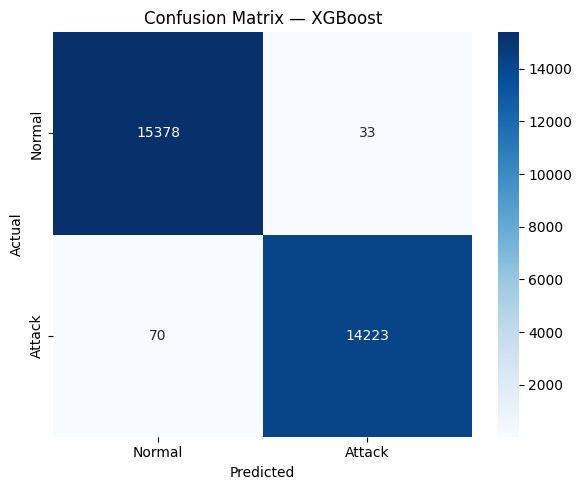

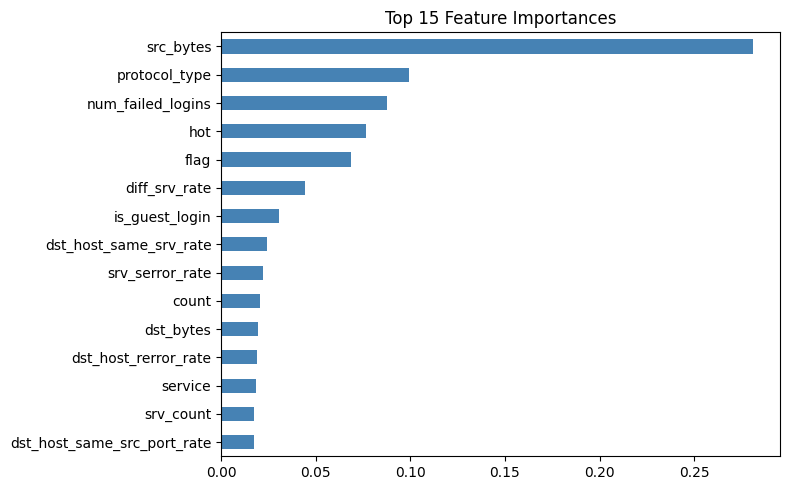

In [21]:
y_pred = results[best_name]["preds"]

print(f"\n📋 Classification Report — {best_name}")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

# Feature importance (Random Forest)
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=feature_names)
    fi.nlargest(15).sort_values().plot(kind="barh", figsize=(8, 5), color="steelblue")
    plt.title("Top 15 Feature Importances")
    plt.tight_layout(); plt.show()

### 6. Exporting for Production
**What it does:**
- Saves the trained model, the scaler, and the label encoders as `.pkl` files.
- Exports a `feature_names.json` to ensure that when you use this model later (e.g., in a VS Code app), the input data is provided in the exact same order.

**Important Points:**
- **The Scaler is Critical:** We must use the *same* scaler object from training to transform new data before prediction, or the model will receive input it doesn't understand.

In [22]:
import os, json
os.makedirs("nids_model", exist_ok=True)

# Save model
joblib.dump(best_model, "nids_model/nids_model.pkl")

# Save scaler
joblib.dump(scaler, "nids_model/scaler.pkl")

# Save label encoders
joblib.dump(le_dict, "nids_model/label_encoders.pkl")

# Save feature names (order matters!)
with open("nids_model/feature_names.json", "w") as f:
    json.dump(feature_names, f)

# Save model metadata
meta = {
    "model_type"   : best_name,
    "accuracy"     : round(results[best_name]["acc"], 4),
    "f1_score"     : round(results[best_name]["f1"], 4),
    "classes"      : ["Normal", "Attack"],
    "cat_columns"  : cat_cols,
    "n_features"   : len(feature_names)
}
with open("nids_model/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("✅ Model artifacts saved to /nids_model/")
print("   ├── nids_model.pkl")
print("   ├── scaler.pkl")
print("   ├── label_encoders.pkl")
print("   ├── feature_names.json")
print("   └── metadata.json")

✅ Model artifacts saved to /nids_model/
   ├── nids_model.pkl
   ├── scaler.pkl
   ├── label_encoders.pkl
   ├── feature_names.json
   └── metadata.json


### 7. Portability
**What it does:**
- Zips all artifacts into a single file and triggers a browser download.

**Important Points:**
- This allows us to move our work from the Colab cloud environment to a local deployment or a web server.

In [23]:
!zip -r nids_model.zip nids_model/

from google.colab import files
files.download("nids_model.zip")
print("✅ Download started!")

  adding: nids_model/ (stored 0%)
  adding: nids_model/scaler.pkl (deflated 28%)
  adding: nids_model/metadata.json (deflated 32%)
  adding: nids_model/label_encoders.pkl (deflated 50%)
  adding: nids_model/nids_model.pkl (deflated 66%)
  adding: nids_model/feature_names.json (deflated 66%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
